# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import equinox as eqx
import jax

from pathlib import Path
import matplotlib.colors as mcolors

from hypermagnetics import plots
from hypermagnetics.sources import read_db, configure
from hypermagnetics.fmm_sources import potential2D, field2d_grid
from hypermagnetics.mt_eval import field_mt
from hypermagnetics.models.hyper_mlp import HyperLayer

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

Matches found: 202
Res: 32 Max size: 0.47992128 Min size: 0.0
max value: 1.0157485


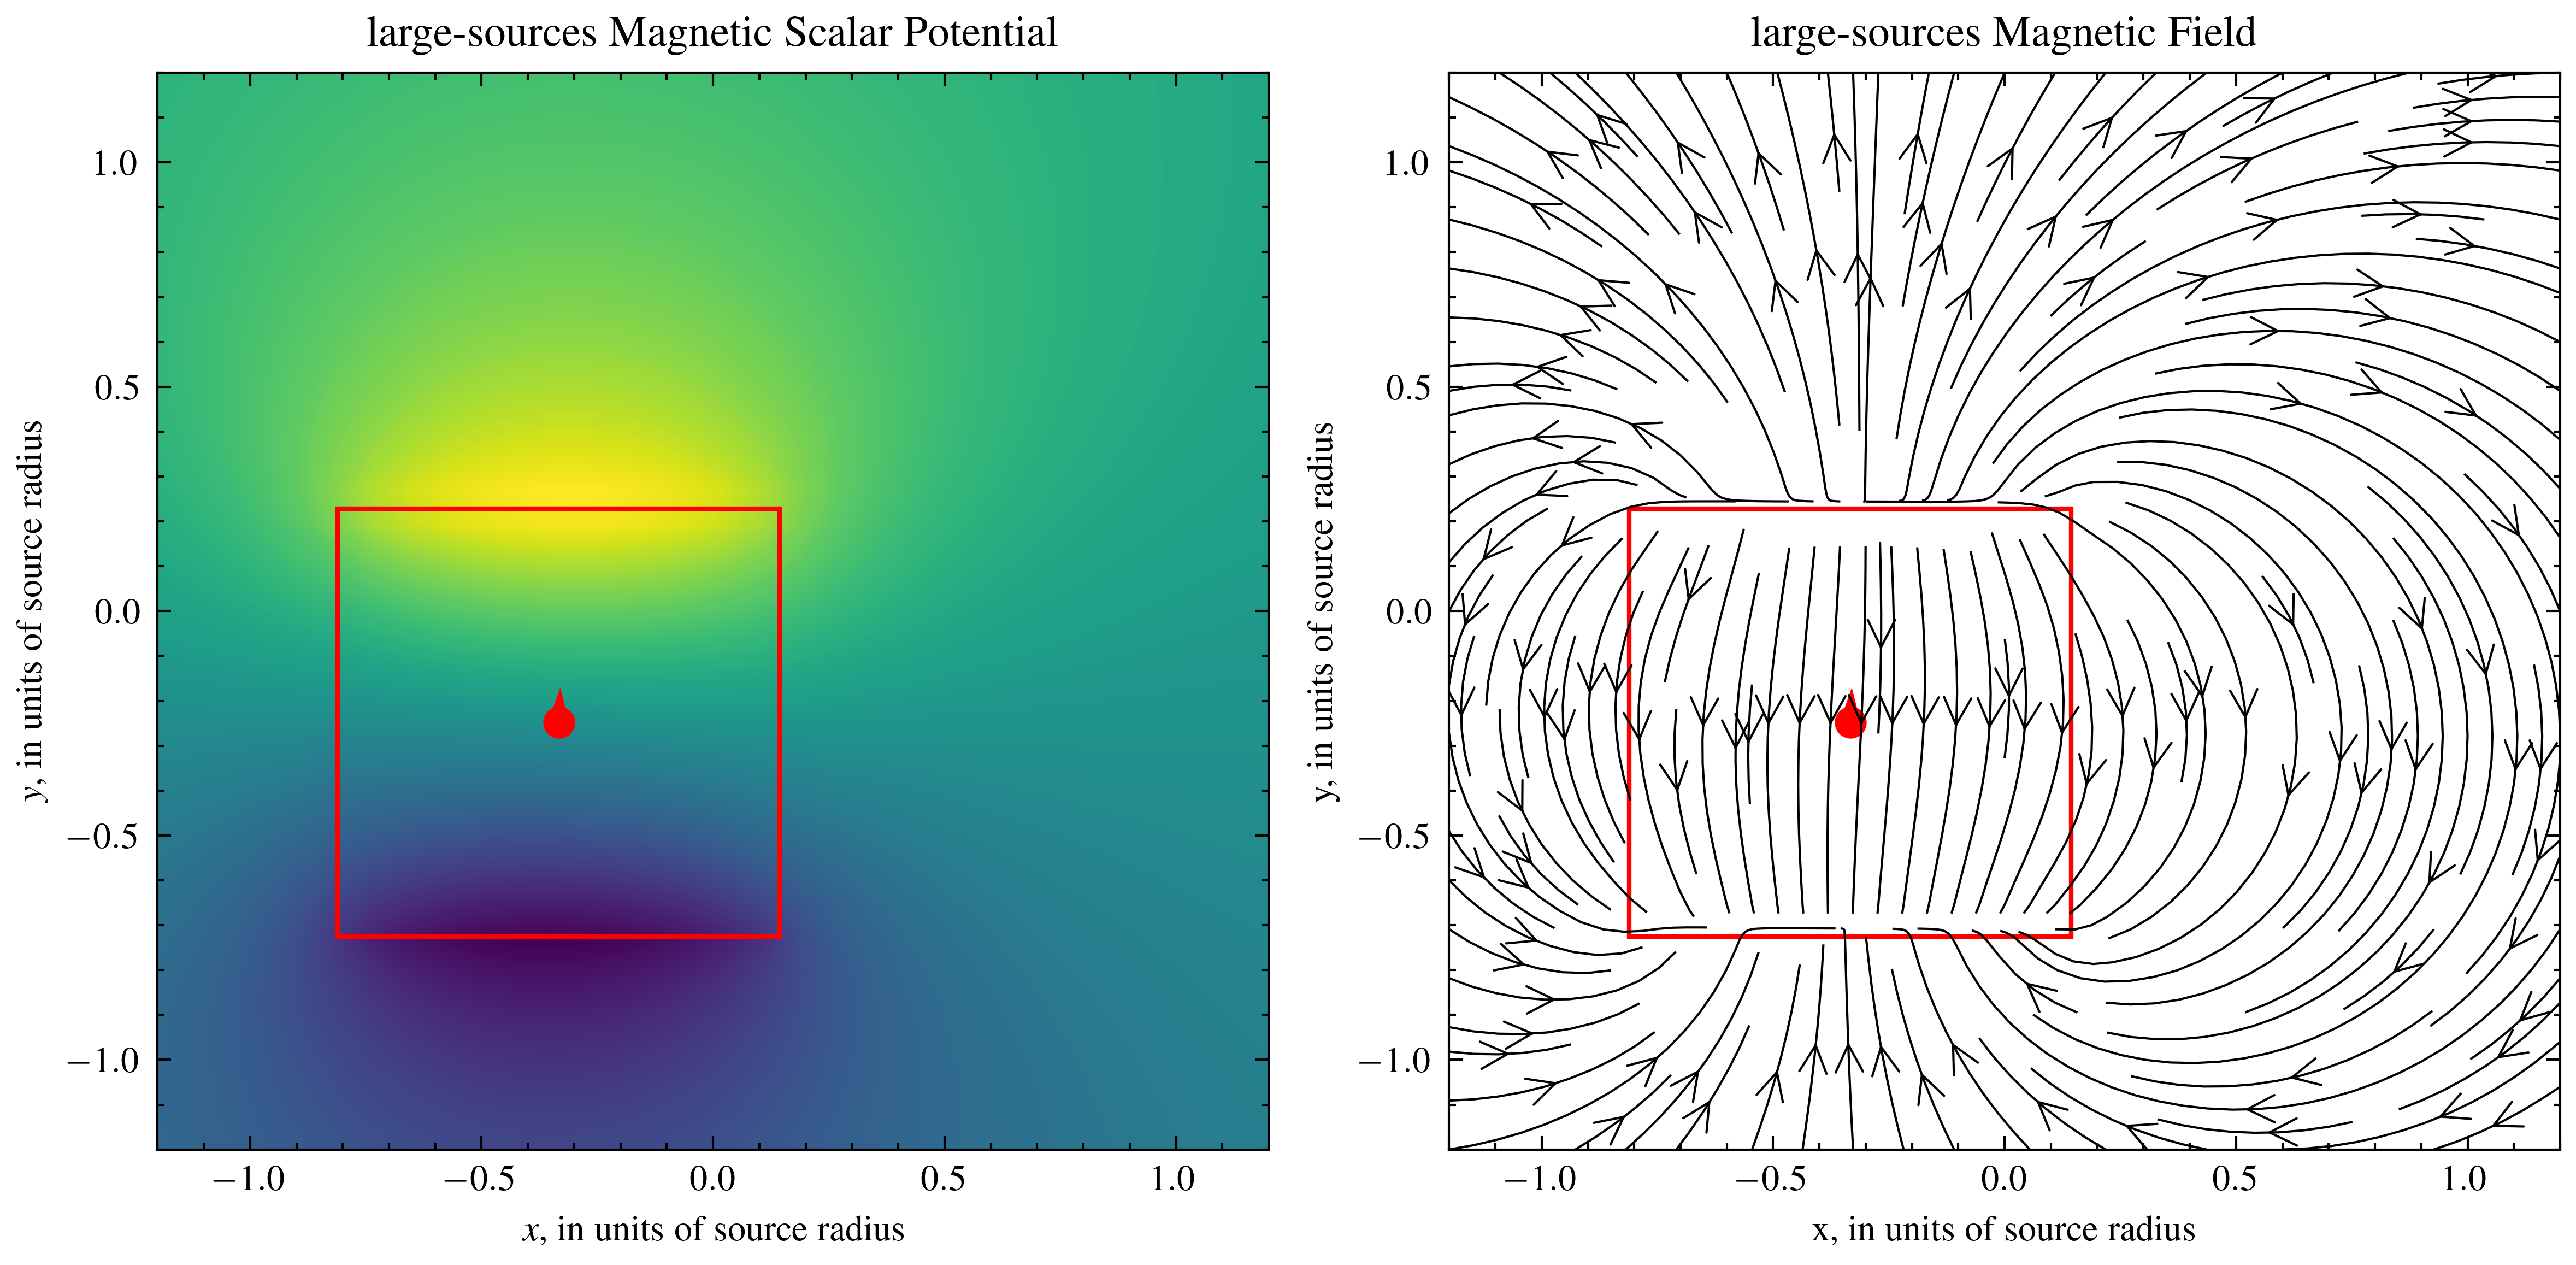

In [2]:
train = read_db("val_eval_large_m_92_1000_1.h5")
idx_small = np.argwhere(train['sources'][:, :, 7] > 0.4)[:,0]
print(f"Matches found: {idx_small.shape[0]}")
# train = read_db("train_res32_large_m_42_200000_1.h5")
extra_n = 'large-sources'
res = int(np.sqrt(train['msp_grid'].shape[1]))
# Stats of dataset
print("Res:", res, "Max size:", train["max_size"], "Min size:", train["min_size"])

idx = idx_small[2]
vmax = np.max(np.abs(train["msp_grid"][idx]))
print("max value:", vmax)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
# scatter = plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=train["msp"][idx], s=0.1, edgecolors='none', norm=norm, cmap='viridis')
# cbar = plt.colorbar(scatter)
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/gt_{extra_n}_plot_{idx}.svg")
plots(train, loc=True, edge=True, idx=idx, output="save", prefix=extra_n)

0.971597 -1.0157485


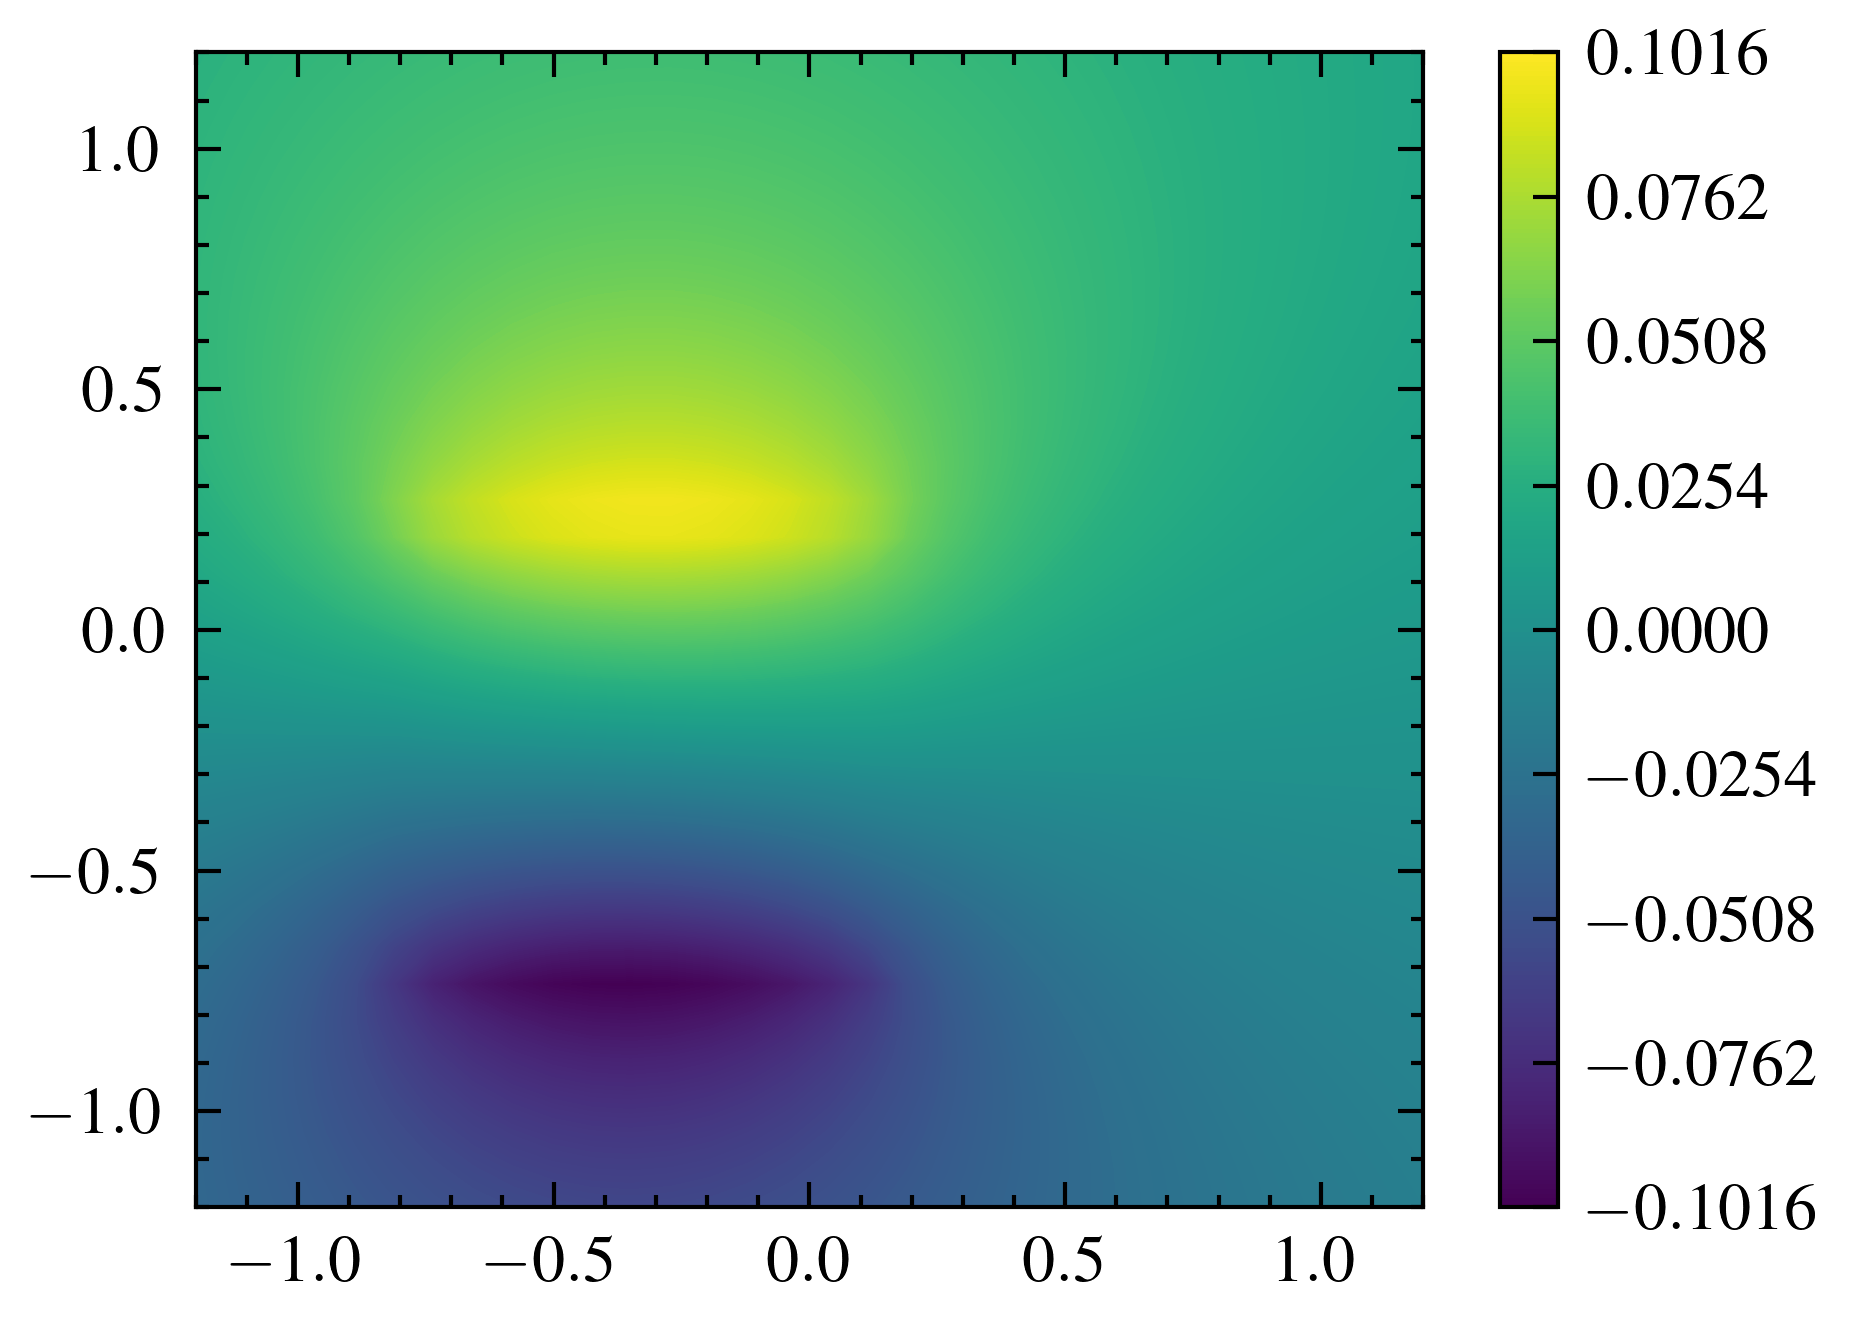

In [3]:
x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
t_msp = train["msp_grid"][idx].reshape((res, res))
print(t_msp.max(), t_msp.min())
vmax_scaled = vmax / 10
vmin_scaled = -vmax / 10
cbar_ticks = np.linspace(vmin_scaled, vmax_scaled, 9)

# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm = mcolors.TwoSlopeNorm(vmin=vmin_scaled, vcenter=0, vmax=vmax_scaled)
levels = np.linspace(vmin_scaled, vmax_scaled, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid, y_grid, np.clip(t_msp / 10, vmin_scaled, vmax_scaled), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/gt_{extra_n}_plot_{idx}.png")

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


## Directly from FMM2D

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

# FC-ILR field plots

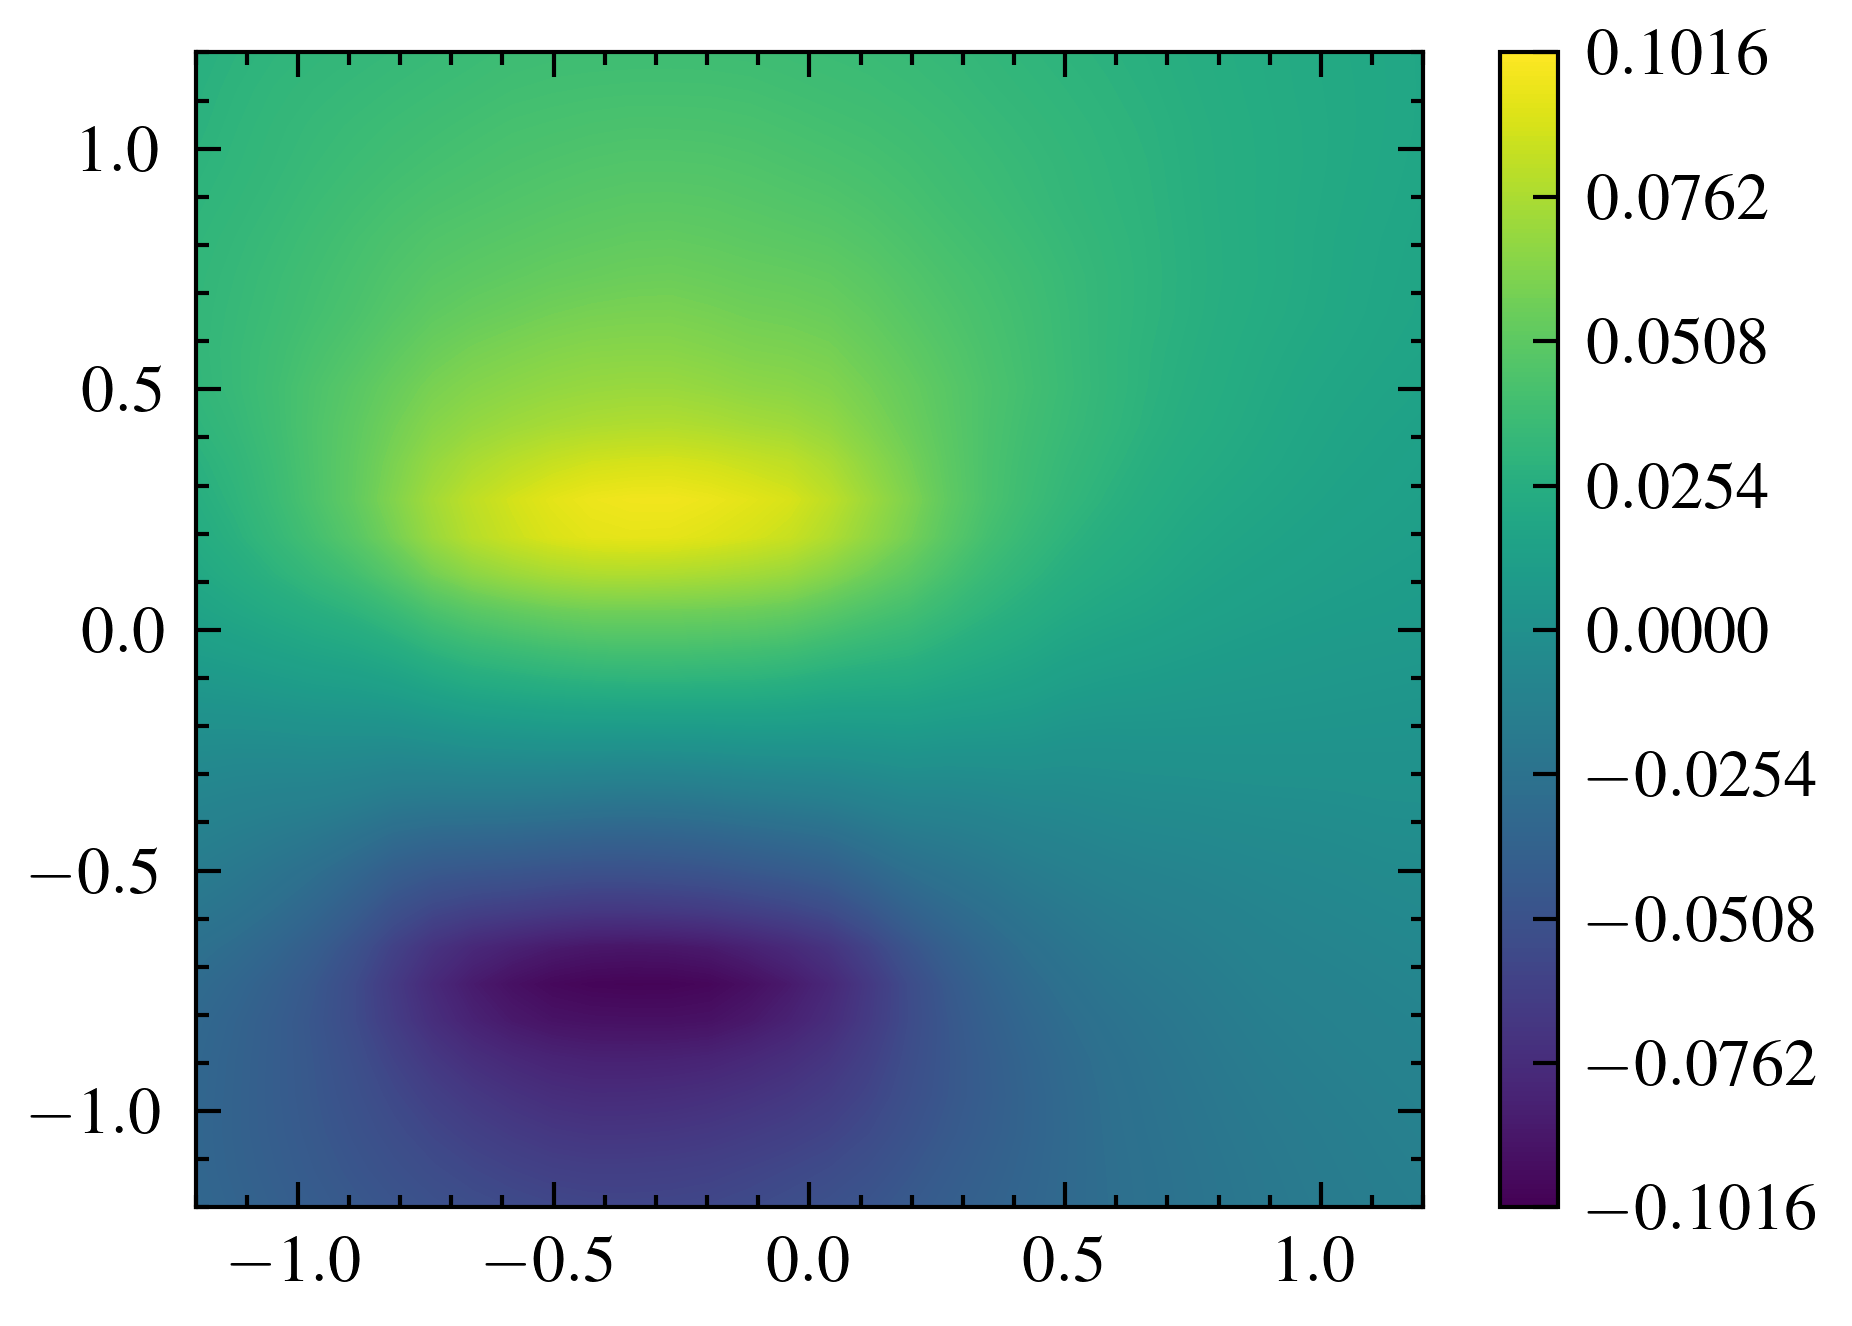

In [4]:
model_cfg = HyperLayer(
    width=400,
    depth=3,
    hwidth=2,
    hdepth=3,
    seed=42,
)

model_folder = Path().resolve() / '..' / 'models'
model_path = f"{model_folder}/fc_ilr_400_200k_res32_large_m.eqx"
model = eqx.tree_deserialise_leaves(model_path, model_cfg)

sim = train.copy()
# sim_f = jax.vmap(model, in_axes=(0, None))(
#     train['sources'][idx:idx+1], train["r"][idx]
# )[0]
# plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=sim_f, s=0.1, edgecolors='none')

# sim['field_grid_model'] = jax.vmap(model.field, in_axes=(0, None))(
#     train['sources'][idx:idx+1], train['grid']
# )[0]

sim['msp_grid_model'] = jax.vmap(model, in_axes=(0, None))(
    train['sources'][idx:idx+1], train['grid']
)[0]
x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
sim_f = sim["msp_grid_model"].reshape((res, res))

contour = plt.contourf(x_grid, y_grid, sim_f/10, levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)
# plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
# plt.title("Relative Error of field [\%]")
plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_{extra_n}_plot_{idx}.png", dpi=300)

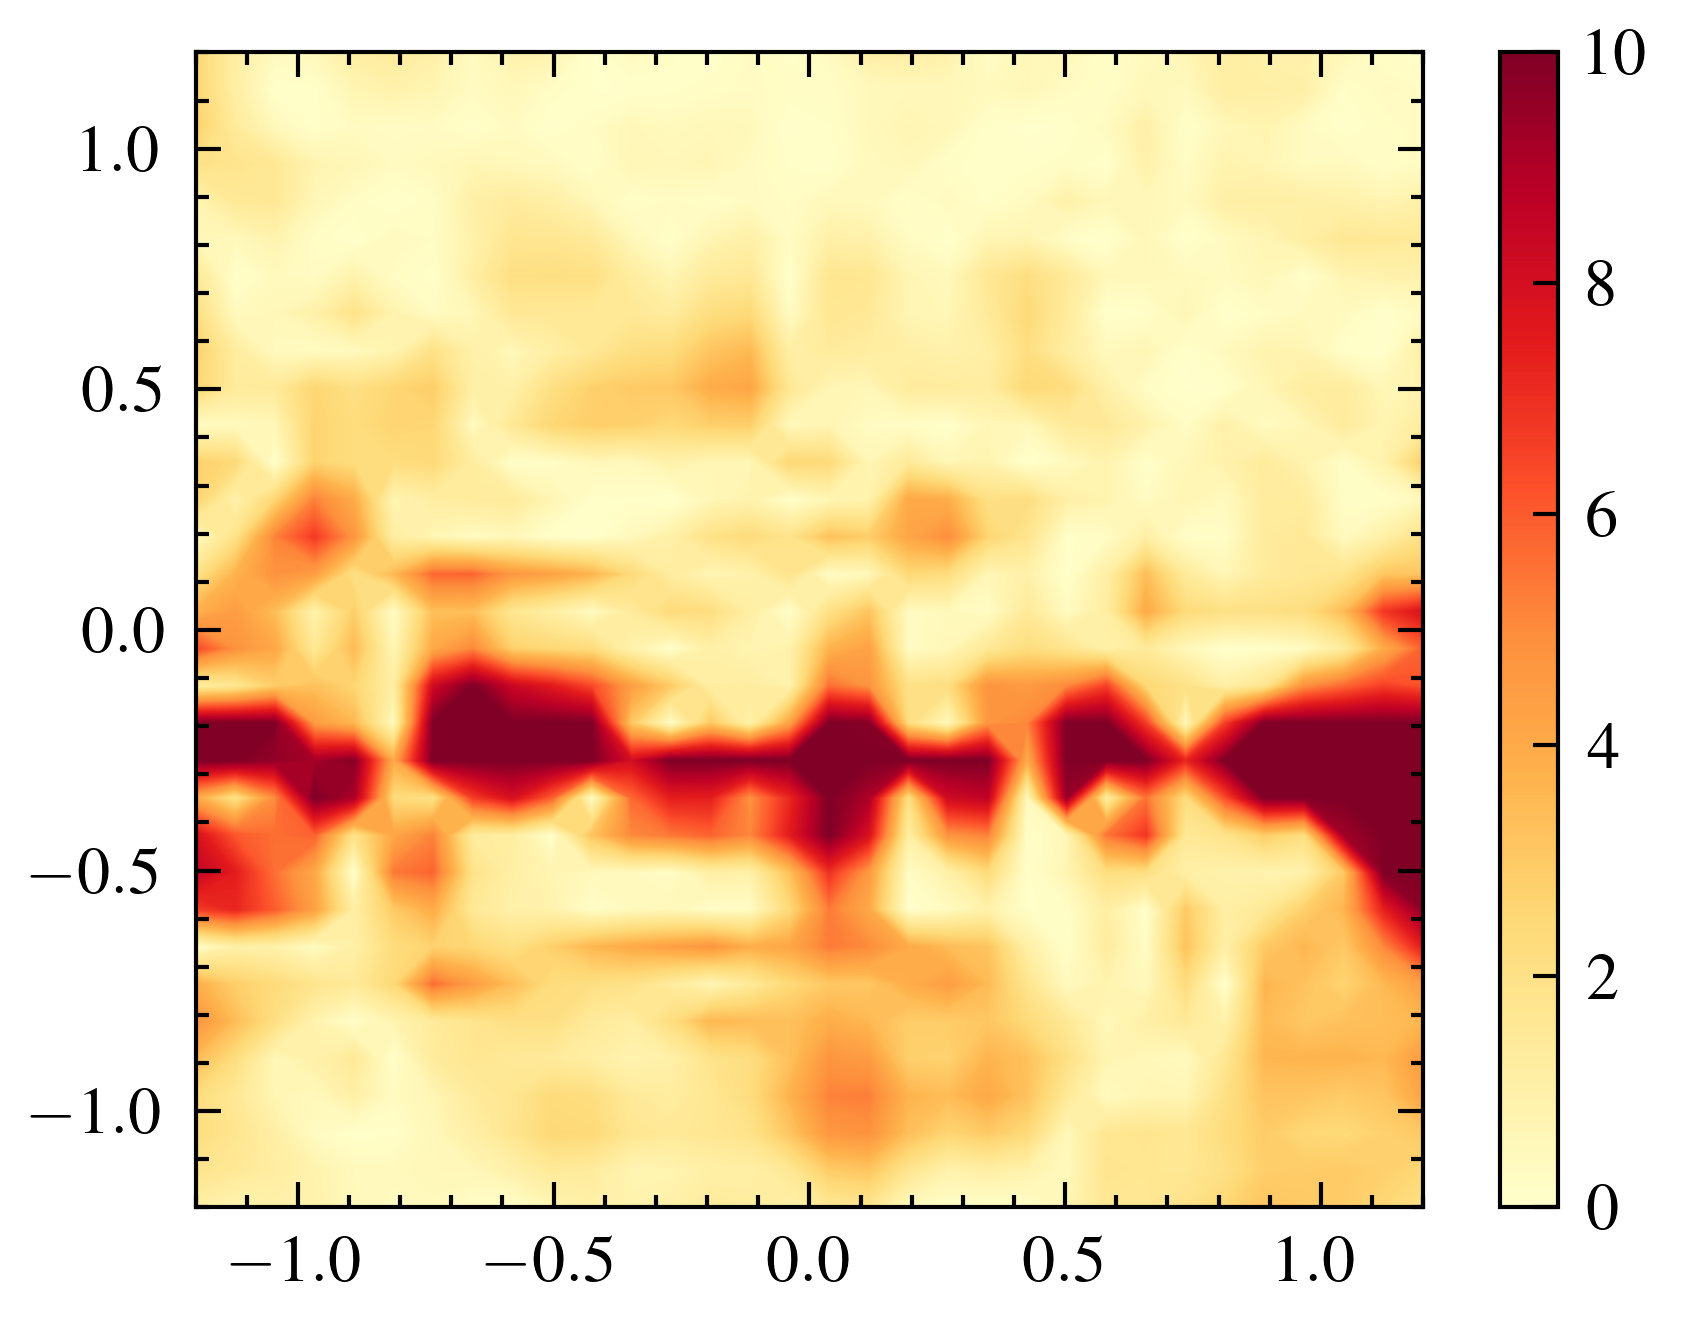

In [5]:
# Error FCILR
err_fcilr = (np.abs(sim_f - t_msp) / np.abs(t_msp)) * 100
vmax_rel = 10
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
# norm = mcolors.LogNorm(vmin=vmin_rel, vmax=vmax_rel)
contour_rel = plt.contourf(x_grid, y_grid, np.clip(err_fcilr, vmin_rel, vmax_rel), cmap="YlOrRd", levels=levels_rel)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.array([0, 2, 4, 6, 8, 10]))
plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_plot_{idx}.png", dpi=300)

# err_fcilr = (np.abs(sim_f - train["msp"][idx]) / np.abs(train["msp"][idx])) * 100
# scatter_rel = plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=err_fcilr, s=0.1, edgecolors='none', cmap="YlOrRd", vmin=0, vmax=25)
# vmax_rel = 25
# cbar = plt.colorbar(scatter_rel)
# cbar.set_ticks(np.linspace(0, vmax_rel, vmax_rel//5 + 1))
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_plot_{idx}.png", dpi=300)

In [6]:
# plt.hist(err_fcilr.flatten(), bins=200, range=(0, 600))
# plt.yscale("log")
# print("Mean:", np.mean(err_fcilr))
print("Median:", np.median(err_fcilr))
print("Size:", train["sources"][idx, :, 7])
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_hist_{idx}.png", dpi=300)

Median: 1.3890919751870001
Size: [0.47697482]
